# Dpi Setting

In [2]:
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 100 # 300

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
from package_sampling.sampling import up_tille, up_brewer, up_systematic, up_max_entropy
from package_sampling.utils import inclusion_probabilities


In [5]:
import os

print(os.getcwd())

/home/divar/projects/graphical-sampling/Simulations ipynb


In [6]:
import os
os.chdir('/home/divar/projects/graphical-sampling')

### Dependencies

### Python

In [7]:
# !pip install -q git+https://github.com/mehdimhb/geometric-sampling@dev
# !pip install git+https://github.com/mehdimhb/geometric-sampling@legacy-measure

In [8]:
!apt-get install -y r-base
#!pip install -q rpy2 tqdm


E: Could not open lock file /var/lib/dpkg/lock-frontend - open (13: Permission denied)
E: Unable to acquire the dpkg frontend lock (/var/lib/dpkg/lock-frontend), are you root?


In [9]:
from rpy2.robjects.packages import importr

import numpy as np
from rpy2.robjects import numpy2ri, default_converter, globalenv
from rpy2.robjects.conversion import localconverter

/home/divar/projects/graphical-sampling/.venv/lib/python3.12/site-packages/rpy2/rinterface/__init__.py:1211: UserWarning: Environment variable "LD_LIBRARY_PATH" redefined by R and overriding existing variable. Current: "/usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server", R: "/usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server:/usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server"
  warnings.warn(
/home/divar/projects/graphical-sampling/.venv/lib/python3.12/site-packages/rpy2/rinterface/__init__.py:1211: UserWarning: Environment variable "R_LIBS_SITE" redefined by R and overriding existing variable. Current: "/usr/local/lib/R/site-library/:/usr/local/lib/R/site-library:/usr/lib/R/site-library:/usr/lib/R/library", R: "/usr/local/lib/R/site-library/:/usr/local/lib/R/site-library/:/usr/local/lib/R/site-library/:/usr/local/lib/R/site-library:/usr/lib/R/site-library:/usr/lib/R/library:/usr/lib/R/library:/usr/lib/R/

In [10]:
%load_ext rpy2.ipython

### R

In [11]:
%%R

#library(spcosa)
#ibrary(spsurvey)
if(!require(WaveSampling)){
    install.packages("WaveSampling")
    library(WaveSampling)
}
if(!require(sampling)){
    install.packages("sampling")
    library(sampling)
}
if(!require(BalancedSampling)){
    install.packages("BalancedSampling")
    library(BalancedSampling)
}

Loading required package: WaveSampling
Loading required package: Matrix
Loading required package: sampling
Loading required package: BalancedSampling


### Imports

In [12]:
import matplotlib as mpl
import numpy as np
from rpy2.robjects import r, numpy2ri
import rpy2.robjects as ro
from matplotlib import pyplot as plt
from itertools import combinations
from collections import OrderedDict
import pandas as pd
import graphical_sampling as gs
from tqdm import tqdm
from tqdm.contrib import tenumerate
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

#numpy2ri.activate()

rng = gs.random.rng()

/home/divar/projects/graphical-sampling/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Functions

In [13]:
autumn_cmap = plt.get_cmap('autumn')
plasma_cmap = plt.get_cmap('plasma')

def get_autumn_colors(n_clusters):
    """Returns n_clusters colors from the autumn colormap."""
    colors = autumn_cmap(np.linspace(0.15, 0.95, n_clusters))
    return colors

def get_plasma_colors(n_clusters):
    """Returns n_clusters colors from the plasma colormap."""
    colors = plasma_cmap(np.linspace(0.15, 0.95, n_clusters))
    return colors

# Example usage:
n = 10  # Number of clusters
n_clusters = n
import matplotlib.pyplot as plt
import numpy as np

def lighten_color(color, amount=0.5):
    import matplotlib.colors as mc
    import colorsys
    try:
        c = mc.cnames[color]
    except:
        c = color
    c = np.array(mc.to_rgb(c))
    white = np.array([1, 1, 1])
    return tuple((1 - amount) * c + amount * white)

n_clusters = n
base_colors = plt.cm.plasma(np.linspace(0, 1, n_clusters))
light_colors = [lighten_color(col, 0.5) for col in base_colors]

autumn_colors = get_autumn_colors(n_clusters)
plasma_colors = get_plasma_colors(n_clusters)
plasma_colors = light_colors

In [14]:
import numpy as np
from scipy.spatial import ConvexHull, QhullError
from matplotlib.patches import Polygon

def plot_convex_hull(points, ax, color, alpha=0.33, edge_color="gray", line_width=0.6):
    """Plot a convex hull safely. Always returns (ax, hull or None)."""
    pts = np.asarray(points, dtype=float)
    if pts.shape[0] < 3:
        return ax, None
    try:
        # QJ adds tiny noise to handle collinear/duplicate points robustly
        hull = ConvexHull(pts, qhull_options='QJ')
        poly = Polygon(
            pts[hull.vertices],
            closed=True,
            facecolor=color,
            alpha=alpha,
            edgecolor=edge_color,
            linewidth=line_width,
            zorder=1
        )
        ax.add_patch(poly)
        return ax, hull
    except (QhullError, ValueError):
        # Fallback: skip hull if still degenerate
        return ax, None


# Simulations

### Generte coordinates and UP

In [19]:
import os
import numpy as np
import pandas as pd

BASE_DIR = "/home/divar/projects/graphical-sampling/populations"
pop_files = {
    "grid_eq":    "grid_eq_N=100.csv",
    "grid_uneq":  "grid_uneq_N=100.csv",
    "random_eq":  "random_eq_N=100.csv",
    "random_uneq":"random_uneq_N=100.csv",
    "clust_eq":   "clust_eq_N=100.csv",
    "clust_uneq": "clust_uneq_N=100.csv",
    "meuse_eq":   "meuse_eq_N=100.csv",
    "meuse_uneq": "meuse_uneq_N=100.csv",
    "swiss_eq":   "swiss_eq_fake_N=100.csv",
    "swiss_uneq": "swiss_uneq_fake_N=100.csv",
}

# sampler params
n = 4
n_zones = (2, 2)
zone_builder = "sweep"
units_order  = "spiral"
zones_order  = "spiral"
split_size   = 0.0001

populations   = {}
probabilities = {}
pop_objs      = {}
samplers      = {}

def _read_xyprob(csv_path: str):
    df = pd.read_csv(csv_path)
    xcol = "x" if "x" in df.columns else df.columns[0]
    ycol = "y" if "y" in df.columns else df.columns[1]
    pcol = "prob" if "prob" in df.columns else [c for c in df.columns if c.lower().startswith("prob")][0]
    coords = df[[xcol, ycol]].to_numpy(float)
    probs_raw = df[pcol].to_numpy(float)

    # --- crucial: scale first-order inclusion probabilities to sum to n ---
    total = probs_raw.sum()
    if total <= 0:
        raise ValueError(f"{os.path.basename(csv_path)} has non-positive total prob.")
    probs = probs_raw * (n / total)

    # tiny epsilon to avoid exact zeros if your code dislikes them (optional)
    # probs = np.clip(probs, 1e-12, None)

    # sanity check: warn if any > 1 (rare but possible with very skewed probs)
    if (probs > 1).any():
        print(f"Warning: some pi_i > 1 in {os.path.basename(csv_path)} after scaling.")

    return coords, probs

# read & build objects
for key, fname in pop_files.items():
    base = key.split("_")[0]
    csv_path = os.path.join(BASE_DIR, fname)

    coords, probs = _read_xyprob(csv_path)
    probabilities[key] = probs
    if base not in populations:
        populations[base] = coords

    pop = gs.sampling.Population(coords=coords, probs=probs)
    pop_objs[key] = pop

    hard = gs.sampling.KMeansSampler(
        population=pop,
        n=n,
        n_zones=n_zones,
        zone_builder=zone_builder,
        units_order=units_order,
        zones_order=zones_order,
        split_size=split_size,
    )
    samplers[key] = hard

print("Loaded keys:", sorted(pop_objs.keys()))
print("Sum of probs (should be n):", {k: round(v.sum(), 6) for k, v in probabilities.items()})


Loaded keys: ['clust_eq', 'clust_uneq', 'grid_eq', 'grid_uneq', 'meuse_eq', 'meuse_uneq', 'random_eq', 'random_uneq', 'swiss_eq', 'swiss_uneq']
Sum of probs (should be n): {'grid_eq': np.float64(4.0), 'grid_uneq': np.float64(4.0), 'random_eq': np.float64(4.0), 'random_uneq': np.float64(4.0), 'clust_eq': np.float64(4.0), 'clust_uneq': np.float64(4.0), 'meuse_eq': np.float64(4.0), 'meuse_uneq': np.float64(4.0), 'swiss_eq': np.float64(4.0), 'swiss_uneq': np.float64(4.0)}


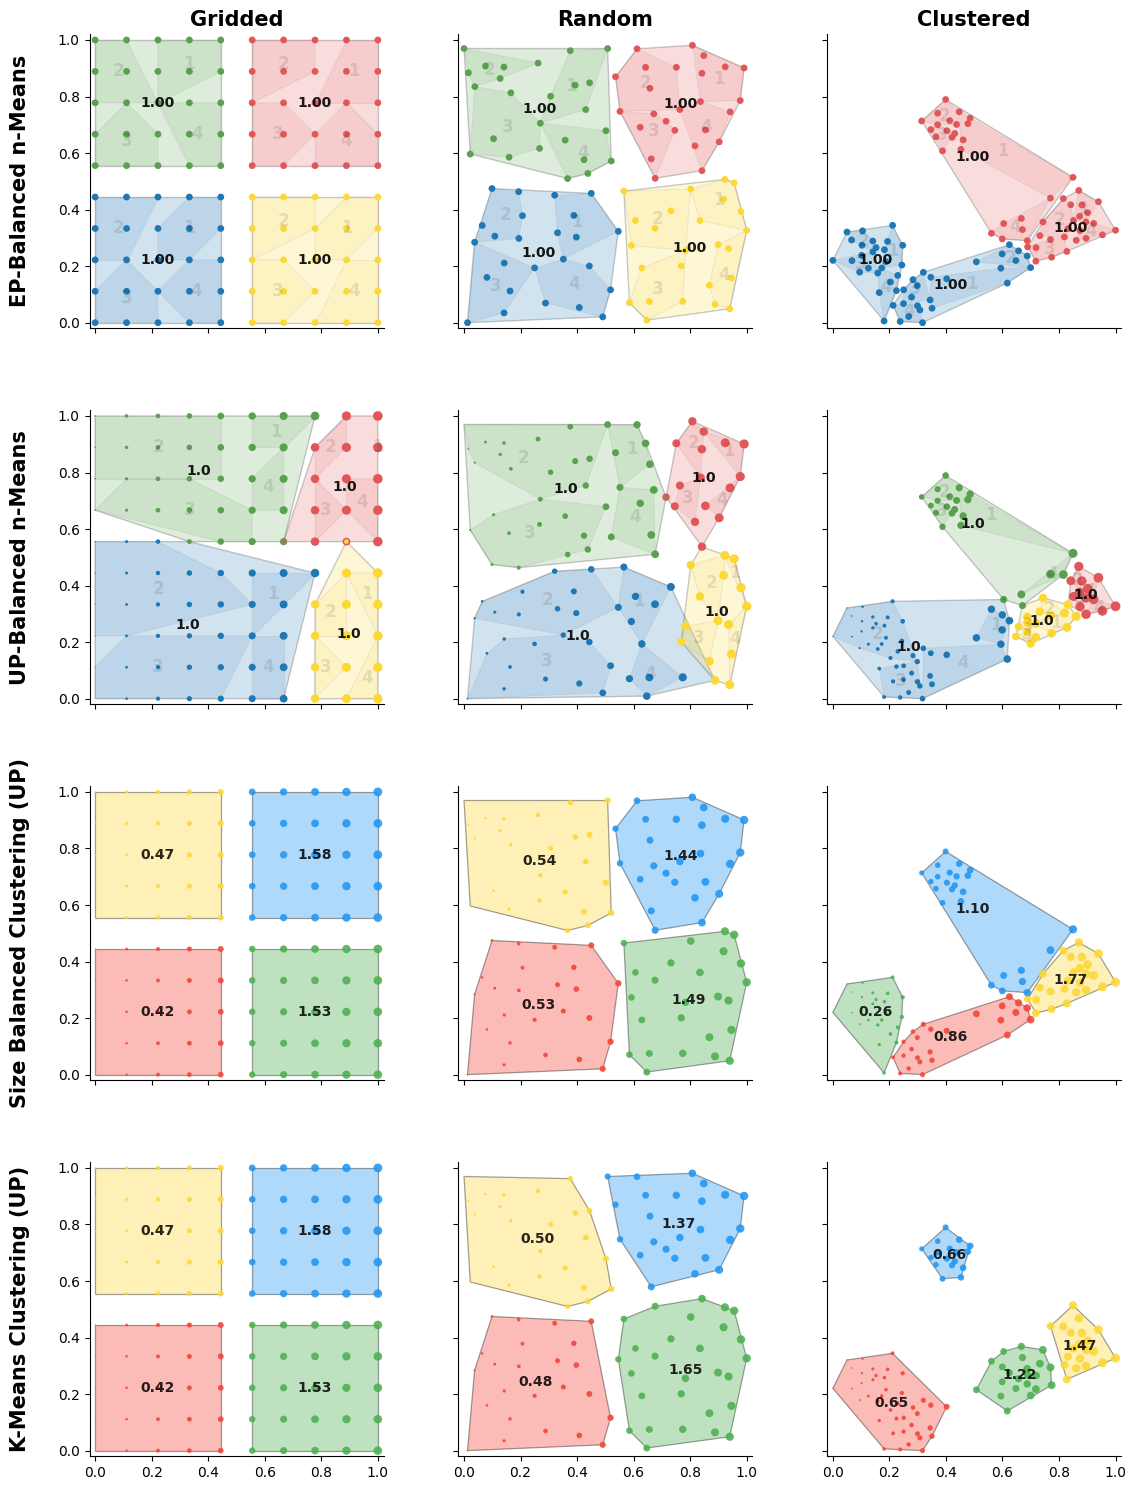

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from k_means_constrained import KMeansConstrained

# expects: pop_objs, samplers, (optional) backgrounds dict
# also expects your plot_convex_hull(points, ax, ...) function to be defined

# ---------- palette ----------
bardi_colors = [
    "#2196F3", "#FDD835", "#4CAF50", "#F44336",
    "#FF9800", "#9C27B0", "#E91E63", "#00BCD4",
    "#BDBDBD", "#FFD700"
]

def get_sorted_cluster_indices_by_lexico_centroids(centroids):
    order = np.lexsort((centroids[:, 0], centroids[:, 1]))
    label_to_color = np.zeros_like(order)
    for c, lab in enumerate(order): label_to_color[lab] = c
    return label_to_color, centroids[order]

def maybe_background(ax, model):
    base = model.split('_')[0]
    bg = globals().get('backgrounds', {}).get(base, None)
    if bg is not None:
        bg.plot(ax=ax, color="none", edgecolor="#4169E1", linewidth=2, alpha=0.8, zorder=0)

# ---------- layout ----------
n_clusters = n
models     = ['grid', 'random', 'clust']   # adjust if you want meuse/swiss
pop_titles = ['Gridded', 'Random', 'Clustered']
row_labels = [
    "EP-Balanced n-Means",
    "UP-Balanced n-Means",
    "Size Balanced Clustering (UP)",
    "K-Means Clustering (UP)",
]

fig, axes = plt.subplots(4, 3, figsize=(12, 15), sharex=True, sharey=True)

for col, model in enumerate(models):
    # ---------------- Row 1: GS (EP) ----------------
    ax = axes[0, col]
    maybe_background(ax, model)
    pop_eq  = pop_objs[f'{model}_eq']
    hard_eq = samplers[f'{model}_eq']
    gs.plot(pop_eq, hard_eq.clusters, ax=ax, size_scale=600)
    ax.set_title(pop_titles[col], fontsize=15, fontweight='bold')

    # (A) overlay sum of probs per GS cluster
    for cl in hard_eq.clusters:
        idx_share = cl.get_index_share(reduce=True)
        if idx_share.size == 0: continue
        idx    = idx_share[:, 0].astype(int)
        share  = idx_share[:, 1]
        psum   = float(np.sum(pop_eq.probs[idx] * share))
        center = pop_eq.coords[idx].mean(axis=0)
        ax.text(center[0], center[1], f"{psum:.2f}",
                color="black", fontsize=10, weight="bold",
                ha="center", va="center", alpha=0.9, zorder=5)

    # ---------------- Row 2: GS (UP) ----------------
    ax = axes[1, col]
    maybe_background(ax, model)
    pop_uneq  = pop_objs[f'{model}_uneq']
    hard_uneq = samplers[f'{model}_uneq']
    gs.plot(pop_uneq, hard_uneq.clusters, ax=ax, size_scale=600)

    # (A) overlay sum of probs per GS cluster
    for cl in hard_uneq.clusters:
        idx_share = cl.get_index_share(reduce=True)
        if idx_share.size == 0: continue
        idx    = idx_share[:, 0].astype(int)
        share  = idx_share[:, 1]
        psum   = float(np.sum(pop_uneq.probs[idx] * share))
        center = pop_uneq.coords[idx].mean(axis=0)
        ax.text(center[0], center[1], f"{psum:.1f}",
                color="black", fontsize=10, weight="bold",
                ha="center", va="center", alpha=0.9, zorder=5)

    # Prep once for rows 3–4
    X      = pop_uneq.coords
    probs  = pop_uneq.probs
    colors = bardi_colors[:n_clusters]

    # ---------------- Row 3: Size-balanced KMeans ----------------
    ax = axes[2, col]
    maybe_background(ax, model)

    kmeans_const = KMeansConstrained(
        n_clusters=n_clusters,
        size_min=int(X.shape[0] / n_clusters),
        size_max=int(np.ceil(X.shape[0] / n_clusters)),
        random_state=1
    ).fit(X)

    labels = kmeans_const.labels_
    centroids = np.array([X[labels == i].mean(axis=0) if np.any(labels == i) else np.array([np.nan, np.nan])
                          for i in range(n_clusters)])
    label_to_color, _ = get_sorted_cluster_indices_by_lexico_centroids(centroids)
    remapped = label_to_color[labels]

    for cidx in range(n_clusters):
        idx = (remapped == cidx)
        pts = X[idx]
        if pts.size == 0: continue
        # (B) ensure convex hull drawn for bottom rows
        ax, _ = plot_convex_hull(pts, ax, color=colors[cidx], alpha=0.36,
                                 edge_color='black', line_width=0.9)
        ax.scatter(pts[:, 0], pts[:, 1], color=colors[cidx],
                   s=probs[idx]*500, alpha=0.88, edgecolors="none", zorder=2)
        ax.text(pts[:,0].mean(), pts[:,1].mean(), f"{probs[idx].sum():.2f}",
                color="black", fontsize=10, weight="bold", alpha=0.85,
                ha="center", va="center", zorder=3)

    # ---------------- Row 4: Vanilla KMeans ----------------
    ax = axes[3, col]
    maybe_background(ax, model)

    km = KMeans(n_clusters=n_clusters, random_state=1).fit(X)
    labels = km.labels_
    centroids = np.array([X[labels == i].mean(axis=0) if np.any(labels == i) else np.array([np.nan, np.nan])
                          for i in range(n_clusters)])
    label_to_color, _ = get_sorted_cluster_indices_by_lexico_centroids(centroids)
    remapped = label_to_color[labels]

    for cidx in range(n_clusters):
        idx = (remapped == cidx)
        pts = X[idx]
        if pts.size == 0: continue
        ax, _ = plot_convex_hull(pts, ax, color=colors[cidx], alpha=0.36,
                                 edge_color='black', line_width=0.9)
        ax.scatter(pts[:, 0], pts[:, 1], color=colors[cidx],
                   s=probs[idx]*500, alpha=0.88, edgecolors="none", zorder=2)
        ax.text(pts[:,0].mean(), pts[:,1].mean(), f"{probs[idx].sum():.2f}",
                color="black", fontsize=10, weight="bold", alpha=0.85,
                ha="center", va="center", zorder=3)

# ---- formatting ----
for ax in axes.ravel():
    ax.set_aspect("equal")
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlabel("")
    ax.set_ylabel("")

for r in range(4):
    axes[r,0].annotate(
        row_labels[r], xy=(0, 0.5),
        xytext=(-axes[r,0].yaxis.labelpad - 12, 0),
        xycoords=axes[r,0].yaxis.label, textcoords='offset points',
        size=15, ha='right', va='center', fontweight='bold', rotation=90
    )

plt.tight_layout()
plt.show()


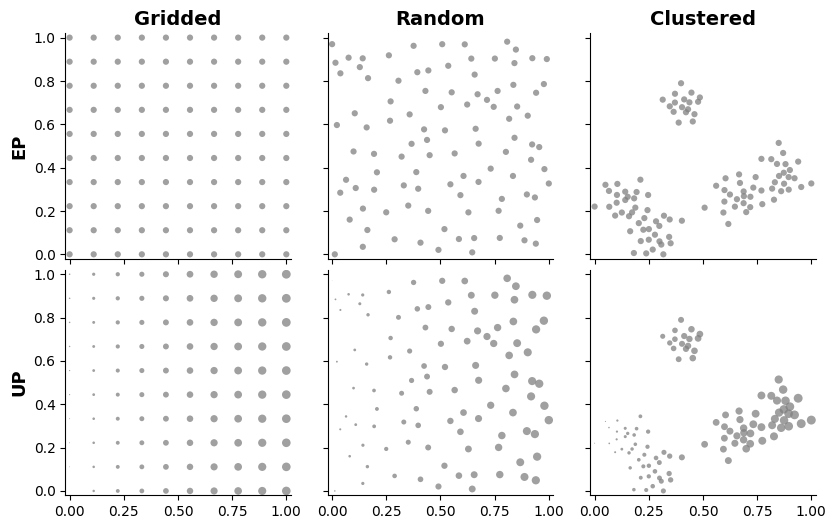

In [16]:
import matplotlib.pyplot as plt

pop_titles = ['Gridded', 'Random', 'Clustered']
row_labels = ["EP", "UP"]
models = ['grid', 'random', 'clust']

fig, axes = plt.subplots(2, 3, figsize=(10, 6), sharex=True, sharey=True)

for col, model in enumerate(models):
    for row, prob_label in enumerate(['eq', 'uneq']):
        ax = axes[row, col]
        pops = pop_objs[f'{model}_{prob_label}']
        if hasattr(pops, 'coords'):
            X = pops.coords
            probs = pops.probs
        else:
            # pops is a DataFrame
            X = pops[['x', 'y']].values
            probs = pops['prob'].values

        ax.scatter(
            X[:, 0], X[:, 1],
            color='gray',
            s=probs * 500,      # <- Here: matches your original code
            alpha=0.75,
            edgecolors='none'
        )
        ax.set_xlim(-0.02, 1.02)
        ax.set_ylim(-0.02, 1.02)
        ax.set_aspect("equal")
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        if row == 0:
            ax.set_title(pop_titles[col], fontsize=14, weight='bold')
        if col == 0:
            ax.set_ylabel(row_labels[row], fontsize=13, weight='bold')
        else:
            ax.set_ylabel("")
plt.subplots_adjust(wspace=0.05, hspace=0.05)
#plt.tight_layout()
plt.show()

### Swiss

In [17]:
# === Cell A: build Swiss objects (fake N=100) ===
import time, os
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.affinity import translate, scale

# Paths
BASE_DIR  = "/home/divar/projects/graphical-sampling/populations"
EQ_FILE   = "swiss_eq_fake_N=100.csv"
UNEQ_FILE = "swiss_uneq_fake_N=100.csv"
SWISS_SHP = "/home/divar/Downloads/ne_50m_admin_0_countries/ne_50m_admin_0_countries.shp"

# Sampler params
n = 8
n_zones      = (2, 2)
zone_builder = "sweep"
units_order  = "spiral"
zones_order  = "spiral"
split_size   = 0.10   # ↑ to 0.2–0.3 for faster builds if needed

def _read_xyprob(path):
    df = pd.read_csv(path)
    xcol = "x" if "x" in df.columns else df.columns[0]
    ycol = "y" if "y" in df.columns else df.columns[1]
    pcol = "prob" if "prob" in df.columns else [c for c in df.columns if c.lower().startswith("prob")][0]
    return df[[xcol, ycol]].to_numpy(float), df[pcol].to_numpy(float)

t0 = time.time()

# Read fake-100 CSVs
coords_eq,   probs_eq_raw   = _read_xyprob(os.path.join(BASE_DIR, EQ_FILE))
coords_uneq, probs_uneq_raw = _read_xyprob(os.path.join(BASE_DIR, UNEQ_FILE))

# Use one coordinate set (they should match)
coords = coords_eq

# Scale probabilities so sum == n (sampler expects sum(pi_i) = n)
def _scale_probs_to_n(p, n):
    total = float(np.sum(p))
    if total <= 0:
        raise ValueError("Non-positive total probability.")
    return p * (n / total)

probs_eq   = _scale_probs_to_n(probs_eq_raw, n)
probs_uneq = _scale_probs_to_n(probs_uneq_raw, n)

# Population objects (your Population class normalizes coords to unit space)
pop_swiss_eq   = gs.sampling.Population(coords=coords, probs=probs_eq)
pop_swiss_uneq = gs.sampling.Population(coords=coords, probs=probs_uneq)

# Samplers (expensive step)
hard_swiss_eq = gs.sampling.KMeansSampler(
    population=pop_swiss_eq, n=n, n_zones=n_zones,
    zone_builder=zone_builder, units_order=units_order,
    zones_order=zones_order, split_size=split_size
)
hard_swiss_uneq = gs.sampling.KMeansSampler(
    population=pop_swiss_uneq, n=n, n_zones=n_zones,
    zone_builder=zone_builder, units_order=units_order,
    zones_order=zones_order, split_size=split_size
)

# Swiss outline → same unit frame as raw coords (min-shift, divide by max span)
world     = gpd.read_file(SWISS_SHP)
swiss_map = world[world['ADMIN'] == 'Switzerland'].to_crs(epsg=2056)

mins      = coords.min(axis=0)
scale_val = float(np.ptp(coords, axis=0).max())
swiss_unit = swiss_map.copy()
if scale_val > 0:
    swiss_unit["geometry"] = swiss_unit.geometry.apply(
        lambda g: scale(
            translate(g, xoff=-mins[0], yoff=-mins[1]),
            xfact=1.0/scale_val, yfact=1.0/scale_val, origin=(0, 0)
        )
    )

# Stash for plotting cell
pop_objs    = {"swiss_eq": pop_swiss_eq, "swiss_uneq": pop_swiss_uneq}
samplers    = {"swiss_eq": hard_swiss_eq, "swiss_uneq": hard_swiss_uneq}
backgrounds = {"swiss": swiss_unit}

print(f"Swiss (fake N=100) built in {time.time()-t0:.2f}s | sums: eq={probs_eq.sum():.2f}, uneq={probs_uneq.sum():.2f}")


Swiss (fake N=100) built in 0.77s | sums: eq=8.00, uneq=8.00


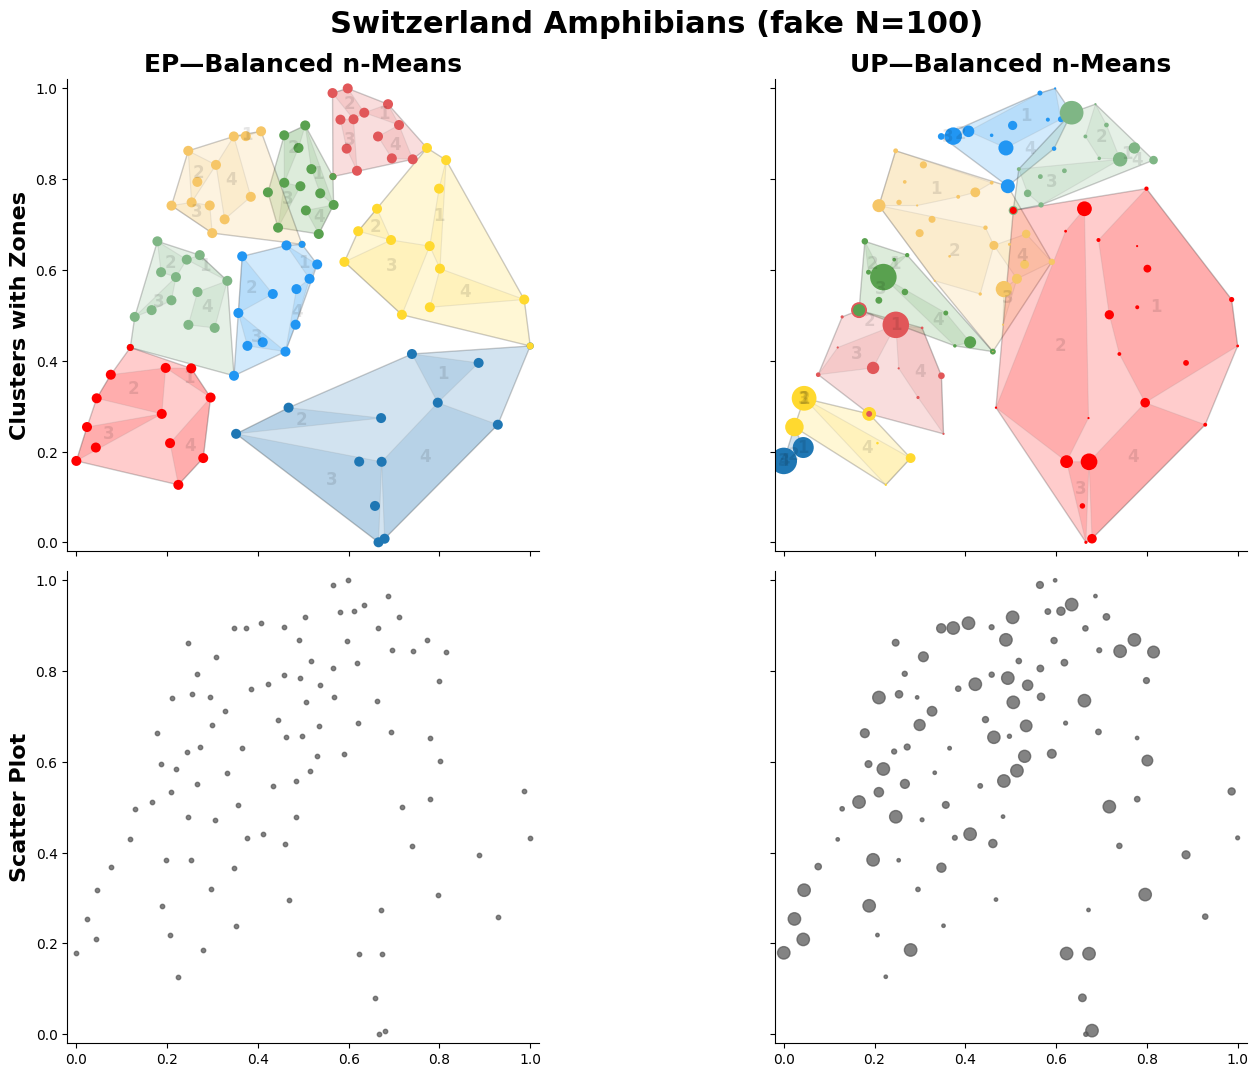

In [21]:
# === Cell B: plot Swiss 2×2 (GS on top, scatters below) ===
import os, numpy as np, pandas as pd, geopandas as gpd
import matplotlib.pyplot as plt
from shapely.affinity import translate, scale

# Guard: rebuild backgrounds['swiss'] if this cell runs alone
if 'backgrounds' not in globals() or 'swiss' not in backgrounds:
    BASE_DIR  = "/home/divar/projects/graphical-sampling/populations"
    SWISS_SHP = "/home/divar/Downloads/ne_50m_admin_0_countries/ne_50m_admin_0_countries.shp"
    df = pd.read_csv(os.path.join(BASE_DIR, "swiss_eq_fake_N=100.csv"))
    coords_raw = df[['x','y']].to_numpy(float)

    world     = gpd.read_file(SWISS_SHP)
    swiss_map = world[world['ADMIN'] == 'Switzerland'].to_crs(epsg=2056)

    mins      = coords_raw.min(axis=0)
    scale_val = float(np.ptp(coords_raw, axis=0).max())
    swiss_unit = swiss_map.copy()
    if scale_val > 0:
        swiss_unit["geometry"] = swiss_unit.geometry.apply(
            lambda g: scale(
                translate(g, xoff=-mins[0], yoff=-mins[1]),
                xfact=1.0/scale_val, yfact=1.0/scale_val, origin=(0, 0)
            )
        )
    backgrounds = {'swiss': swiss_unit}

col_labels = ["EP—Balanced n-Means", "UP—Balanced n-Means"]
size_scale = 650

fig, axes = plt.subplots(2, 2, figsize=(16, 11), sharex=True, sharey=True)

# Bottom row: scatters
for col, key in enumerate(["swiss_eq", "swiss_uneq"]):
    ax = axes[1, col]
    # ⬇⬇ show borders: transparent face + black edge
    backgrounds["swiss"].plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1.2, zorder=0)
    P = pop_objs[key]
    if key.endswith("_eq"):
        ax.scatter(P.coords[:, 0], P.coords[:, 1], c="0.35", s=10, alpha=0.75, zorder=2)
    else:
        s = np.clip(P.probs * 1200, 6, 80)
        ax.scatter(P.coords[:, 0], P.coords[:, 1], c="0.35", s=s, alpha=0.75, zorder=2)

# Top row: gs.plot with clusters
backgrounds["swiss"].plot(ax=axes[0, 0], facecolor="none", edgecolor="black", linewidth=1.2, zorder=0)
gs.plot(pop_objs["swiss_eq"],   samplers["swiss_eq"].clusters,   ax=axes[0, 0], size_scale=size_scale)
axes[0, 0].set_title(col_labels[0], fontsize=18, fontweight="bold")

backgrounds["swiss"].plot(ax=axes[0, 1], facecolor="none", edgecolor="black", linewidth=1.2, zorder=0)
gs.plot(pop_objs["swiss_uneq"], samplers["swiss_uneq"].clusters, ax=axes[0, 1], size_scale=size_scale)
axes[0, 1].set_title(col_labels[1], fontsize=18, fontweight="bold")

# Cosmetics
for ax in axes.ravel():
    ax.set_aspect("equal")
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.set_xlabel(""); ax.set_ylabel("")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    # Optional: ensure white canvas for contrast
    ax.set_facecolor("white")

axes[1,0].set_ylabel("Scatter Plot", fontsize=16, fontweight="bold")
axes[0,0].set_ylabel("Clusters with Zones", fontsize=16, fontweight="bold")

plt.tight_layout(rect=[0, 0.02, 1, 0.97])
plt.suptitle("Switzerland Amphibians (fake N=100)", fontsize=22, fontweight="bold", y=0.995)
plt.show()


In [17]:
import time, os
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.affinity import translate, scale

# --- paths ---
BASE_DIR  = "/home/divar/projects/graphical-sampling/populations"
EQ_FILE   = "swiss_eq_fake_N=100.csv"
UNEQ_FILE = "swiss_uneq_fake_N=100.csv"
SWISS_SHP = "/home/divar/Downloads/ne_50m_admin_0_countries/ne_50m_admin_0_countries.shp"

# --- sampler params ---
n = 8
n_zones      = (2, 2)
zone_builder = "sweep"
units_order  = "spiral"
zones_order  = "spiral"
split_size   = 0.10   # increase (e.g. 0.2–0.3) for faster build, slightly coarser splits

def _read_xyprob(path):
    df = pd.read_csv(path)
    xcol = "x" if "x" in df.columns else df.columns[0]
    ycol = "y" if "y" in df.columns else df.columns[1]
    pcol = "prob" if "prob" in df.columns else [c for c in df.columns if c.lower().startswith("prob")][0]
    return df[[xcol, ycol]].to_numpy(float), df[pcol].to_numpy(float)

t0 = time.time()

# ---- read fake-100 CSVs ----
coords_eq,   probs_eq_raw   = _read_xyprob(os.path.join(BASE_DIR, EQ_FILE))
coords_uneq, probs_uneq_raw = _read_xyprob(os.path.join(BASE_DIR, UNEQ_FILE))

# keep one coordinate set (they should be the same)
coords = coords_eq

# scale probabilities so sum == n (sampler expects first-order inclusion probs summing to n)
probs_eq   = probs_eq_raw   * (n / probs_eq_raw.sum())
probs_uneq = probs_uneq_raw * (n / probs_uneq_raw.sum())

# ---- Population objects (your class normalizes to unit space) ----
pop_swiss_eq   = gs.sampling.Population(coords=coords, probs=probs_eq)
pop_swiss_uneq = gs.sampling.Population(coords=coords, probs=probs_uneq)

# ---- Samplers (expensive step) ----
hard_swiss_eq = gs.sampling.KMeansSampler(
    population=pop_swiss_eq, n=n, n_zones=n_zones,
    zone_builder=zone_builder, units_order=units_order,
    zones_order=zones_order, split_size=split_size
)
hard_swiss_uneq = gs.sampling.KMeansSampler(
    population=pop_swiss_uneq, n=n, n_zones=n_zones,
    zone_builder=zone_builder, units_order=units_order,
    zones_order=zones_order, split_size=split_size
)

# ---- Swiss outline -> same unit frame as raw coords ----
world     = gpd.read_file(SWISS_SHP)
swiss_map = world[world['ADMIN'] == 'Switzerland'].to_crs(epsg=2056)

mins      = coords.min(axis=0)
scale_val = float(np.ptp(coords, axis=0).max())  # if coords already in [0,1], this is ~1
swiss_unit = swiss_map.copy()
# if scale_val > 0:
#     swiss_unit_


In [19]:
# --- ensure 'backgrounds["swiss"]' exists even if the objects cell wasn't run ---
import os, pandas as pd, geopandas as gpd
from shapely.affinity import translate, scale

if 'backgrounds' not in globals() or 'swiss' not in backgrounds:
    BASE_DIR  = "/home/divar/projects/graphical-sampling/populations"
    SWISS_SHP = "/home/divar/Downloads/ne_50m_admin_0_countries/ne_50m_admin_0_countries.shp"

    # read the same coords you used for the fake-100 Swiss population
    df = pd.read_csv(os.path.join(BASE_DIR, "swiss_eq_fake_N=100.csv"))
    coords_raw = df[['x','y']].to_numpy(float)

    world     = gpd.read_file(SWISS_SHP)
    swiss_map = world[world['ADMIN'] == 'Switzerland'].to_crs(epsg=2056)

    mins      = coords_raw.min(axis=0)
    scale_val = float(np.ptp(coords_raw, axis=0).max())
    swiss_unit = swiss_map.copy()
    if scale_val > 0:
        swiss_unit["geometry"] = swiss_unit.geometry.apply(
            lambda g: scale(
                translate(g, xoff=-mins[0], yoff=-mins[1]),
                xfact=1.0/scale_val, yfact=1.0/scale_val, origin=(0, 0)
            )
        )
    backgrounds = {'swiss': swiss_unit}


/home/divar/projects/graphical-sampling/.venv/lib/python3.12/site-packages/rpy2/rinterface/__init__.py:1211: UserWarning: Environment variable "LD_LIBRARY_PATH" redefined by R and overriding existing variable. Current: "/usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server:/usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server", R: "/usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server:/usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server:/usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server"
  warnings.warn(
/home/divar/projects/graphical-sampling/.venv/lib/python3.12/site-packages/rpy2/rinterface/__init__.py:1211: UserWarning: Environment variable "R_LIBS_SITE" redefined by R and overriding existing variable. Current: "/usr/local/lib/R/site-library/:/usr/local/lib/R/site-library/:/usr/local/lib/R/site-library/:/usr/local/lib/R/site-library:/usr/lib/R/site-library:/us

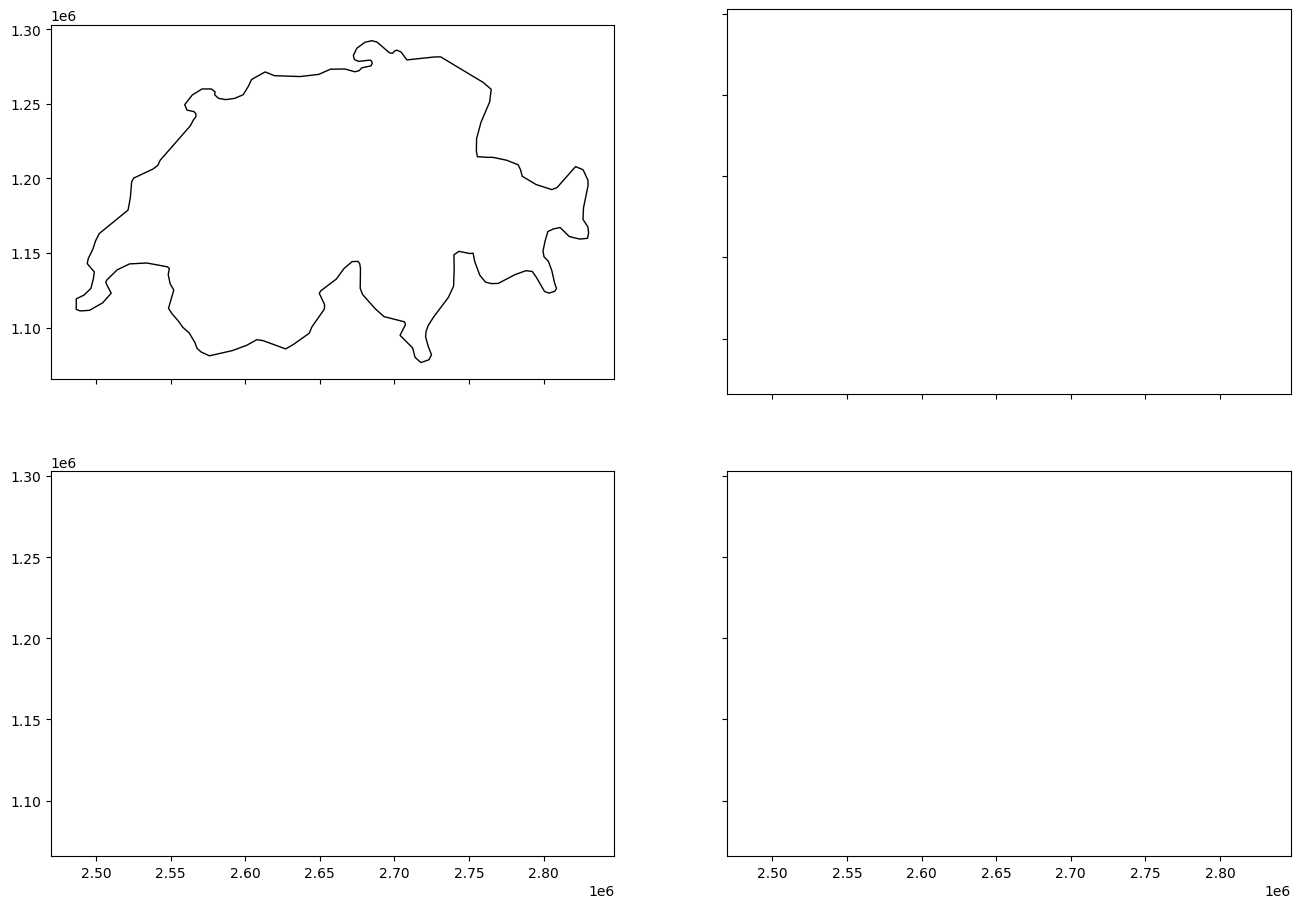

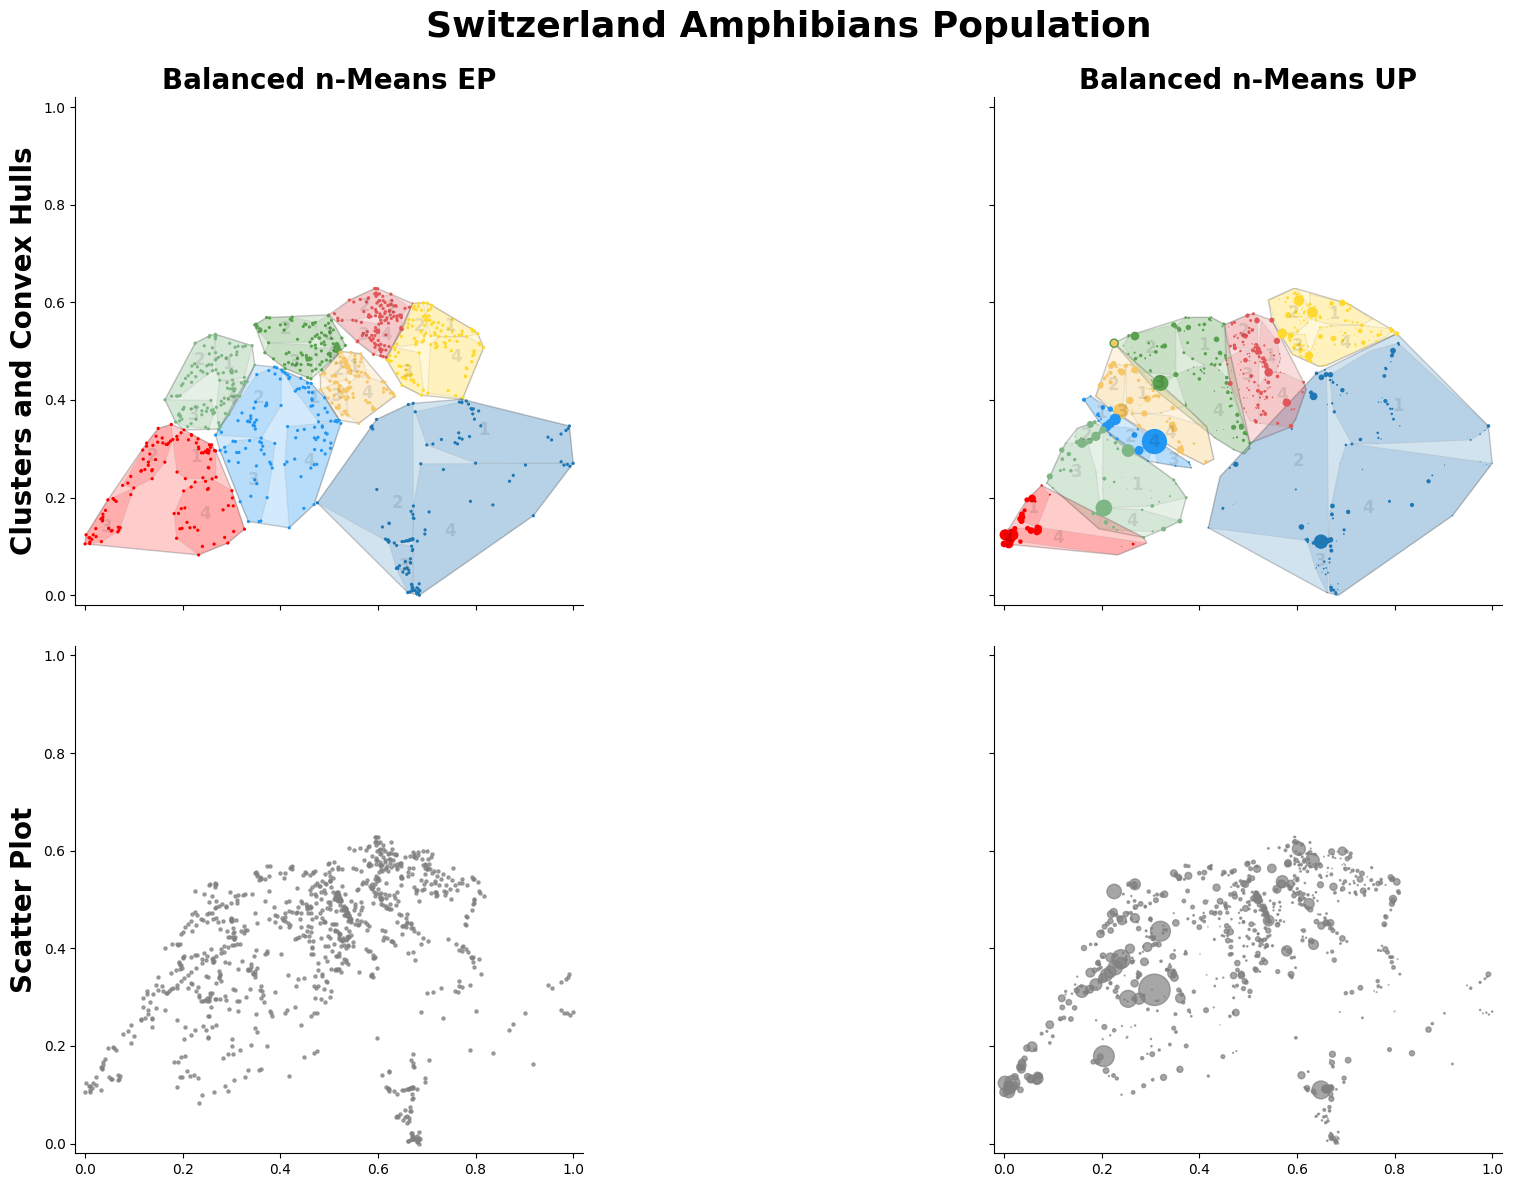

In [23]:

# ... (your existing plotting code)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.affinity import translate, scale

# --- paths ---
swiss_csv = '/home/divar/projects/graphical-sampling/swiss.csv'
swiss_shp = '/home/divar/Downloads/ne_50m_admin_0_countries/ne_50m_admin_0_countries.shp'

# --- params ---
n = 8
n_zones      = (2, 2)
zone_builder = 'sweep'
units_order  = 'spiral'
zones_order  = 'spiral'
size_scale   = 650   # for gs.plot point sizes

# ========= 1) Build Swiss populations & samplers =========
swiss_df   = pd.read_csv(swiss_csv)
coords     = swiss_df[['COORD_X', 'COORD_Y']].to_numpy(float)
N          = coords.shape[0]
area       = swiss_df['AREA'].clip(1e-6, None)

# probabilities (rescale to sum to n for safety)
probs_eq   = (rng.equal_probabilities(n, N) if 'rng' in globals() else np.full(N, n/N))
probs_eq   = probs_eq * (n / probs_eq.sum())

probs_uneq = inclusion_probabilities(area, n)  # your function
probs_uneq = probs_uneq * (n / probs_uneq.sum())

# Population objects (NOTE: your Population class normalizes coords to unit [0,1])
pop_swiss_eq   = gs.sampling.Population(coords=coords, probs=probs_eq)
pop_swiss_uneq = gs.sampling.Population(coords=coords, probs=probs_uneq)

# Samplers
hard_swiss_eq = gs.sampling.KMeansSampler(
    population=pop_swiss_eq, n=n, n_zones=n_zones,
    zone_builder=zone_builder, units_order=units_order,
    zones_order=zones_order, split_size=0.1
)
hard_swiss_uneq = gs.sampling.KMeansSampler(
    population=pop_swiss_uneq, n=n, n_zones=n_zones,
    zone_builder=zone_builder, units_order=units_order,
    zones_order=zones_order, split_size=0.1
)

# (Optional) stash in your dicts for later reuse
pop_objs = {
    'swiss_eq':   pop_swiss_eq,
    'swiss_uneq': pop_swiss_uneq,
}
samplers = {
    'swiss_eq':   hard_swiss_eq,
    'swiss_uneq': hard_swiss_uneq,
}

# ========= 2) Swiss shapefile → same unit frame as Population =========
world     = gpd.read_file(swiss_shp)
swiss_map = world[world['ADMIN'] == 'Switzerland'].to_crs(epsg=2056)

mins       = coords.min(axis=0)
scale_val  = float(np.ptp(coords, axis=0).max())
swiss_unit = swiss_map.copy()
if scale_val > 0:
    swiss_unit['geometry'] = swiss_unit.geometry.apply(
        lambda g: scale(
            translate(g, xoff=-mins[0], yoff=-mins[1]),
            xfact=1.0/scale_val, yfact=1.0/scale_val, origin=(0, 0)
        )
    )

# ========= 3) Plot (2×2) =========
# ========= 3) Plot (2×2) — styled like your Swiss example =========
col_labels = ["Balanced n-Means EP", "Balanced n-Means UP"]

fig, axes = plt.subplots(2, 2, figsize=(18, 12), sharex=True, sharey=True)

# --- BOTTOM ROW: scatters ---
for col, key in enumerate(['swiss_eq', 'swiss_uneq']):
    ax = axes[1, col]
    # White fill + black border, like your example
    backgrounds["swiss"].plot(ax=ax, facecolor="white", edgecolor="black", linewidth=1.0, zorder=0)

    P = pop_objs[key]
    coords_u = P.coords
    probs_u  = P.probs

    if key == 'swiss_eq':
        s = 5  # uniform size like your example
        ax.scatter(coords_u[:, 0], coords_u[:, 1], c="gray", s=s, alpha=0.7, zorder=2)
    else:  # 'swiss_uneq'
        s = probs_u * 1000.0  # same scaling as your example (adjust if needed)
        ax.scatter(coords_u[:, 0], coords_u[:, 1], c="gray", s=s, alpha=0.7, zorder=2)

# --- TOP ROW: GS clusters/hulls over borders ---
# left: EP
backgrounds["swiss"].plot(ax=axes[0, 0], facecolor="white", edgecolor="black", linewidth=1.0, zorder=0)
gs.plot(pop_objs['swiss_eq'], samplers['swiss_eq'].clusters, ax=axes[0, 0], size_scale=size_scale)
axes[0, 0].set_title(col_labels[0], fontsize=20, fontweight='bold')

# right: UP
backgrounds["swiss"].plot(ax=axes[0, 1], facecolor="white", edgecolor="black", linewidth=1.0, zorder=0)
gs.plot(pop_objs['swiss_uneq'], samplers['swiss_uneq'].clusters, ax=axes[0, 1], size_scale=size_scale)
axes[0, 1].set_title(col_labels[1], fontsize=20, fontweight='bold')

# --- Cosmetics (match example) ---
for ax in axes.flatten():
    ax.set_aspect("equal")
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.set_xlabel(""); ax.set_ylabel("")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[1, 0].set_ylabel("Scatter Plot", fontsize=20, fontweight='bold')
axes[0, 0].set_ylabel("Clusters and Convex Hulls", fontsize=20, fontweight='bold')

plt.tight_layout(rect=[0, 0.01, 1, 0.96])
plt.subplots_adjust(wspace=0.08, hspace=0.08)
plt.suptitle("Switzerland Amphibians Population", fontsize=26, fontweight='bold', y=0.995)
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from scipy.spatial import ConvexHull, QhullError
from sklearn.cluster import KMeans
from k_means_constrained import KMeansConstrained

# -- Your custom spatial sampling class, plot_convex_hull function, etc, must be defined

# ----- Load CSVs into populations/probabilities -----
pop_files = {
    'swiss_eq':  'swiss_eq.csv',
    'swiss_uneq': 'swiss_uneq.csv',
}
populations = {}
probabilities = {}
for key, fname in pop_files.items():
    df = pd.read_csv(f"data_samples/{fname}")
    # E.g. populations['grid']=... only once per type; for safety use eq version
    popname = key.split('_')[0]
    if popname not in populations:
        populations[popname] = df[['x','y']].values
    probabilities[key] = df['prob'].values

# --------- Sampling objects for first two rows ----------
n = 10                     # or whatever n you used
pop_objs = {}
for popname, coords in populations.items():
    key_eq = f'{popname}_eq'
    key_uneq = f'{popname}_uneq'
    # You use your spatial-sampling class here
    # Adjust tolerance and split_size as needed!
    hard = gs.sampling.KMeansSpatialSamplingSimple(
        coords, probabilities[key_eq], n=n, n_zones=(2, 2), tolerance=3, split_size=.001)
    pop_objs[key_eq] = hard.popu
    hard = gs.sampling.KMeansSpatialSamplingSimple(
        coords, probabilities[key_uneq], n=n, n_zones=(2,2), tolerance=3, split_size=.0001)
    pop_objs[key_uneq] = hard.popu


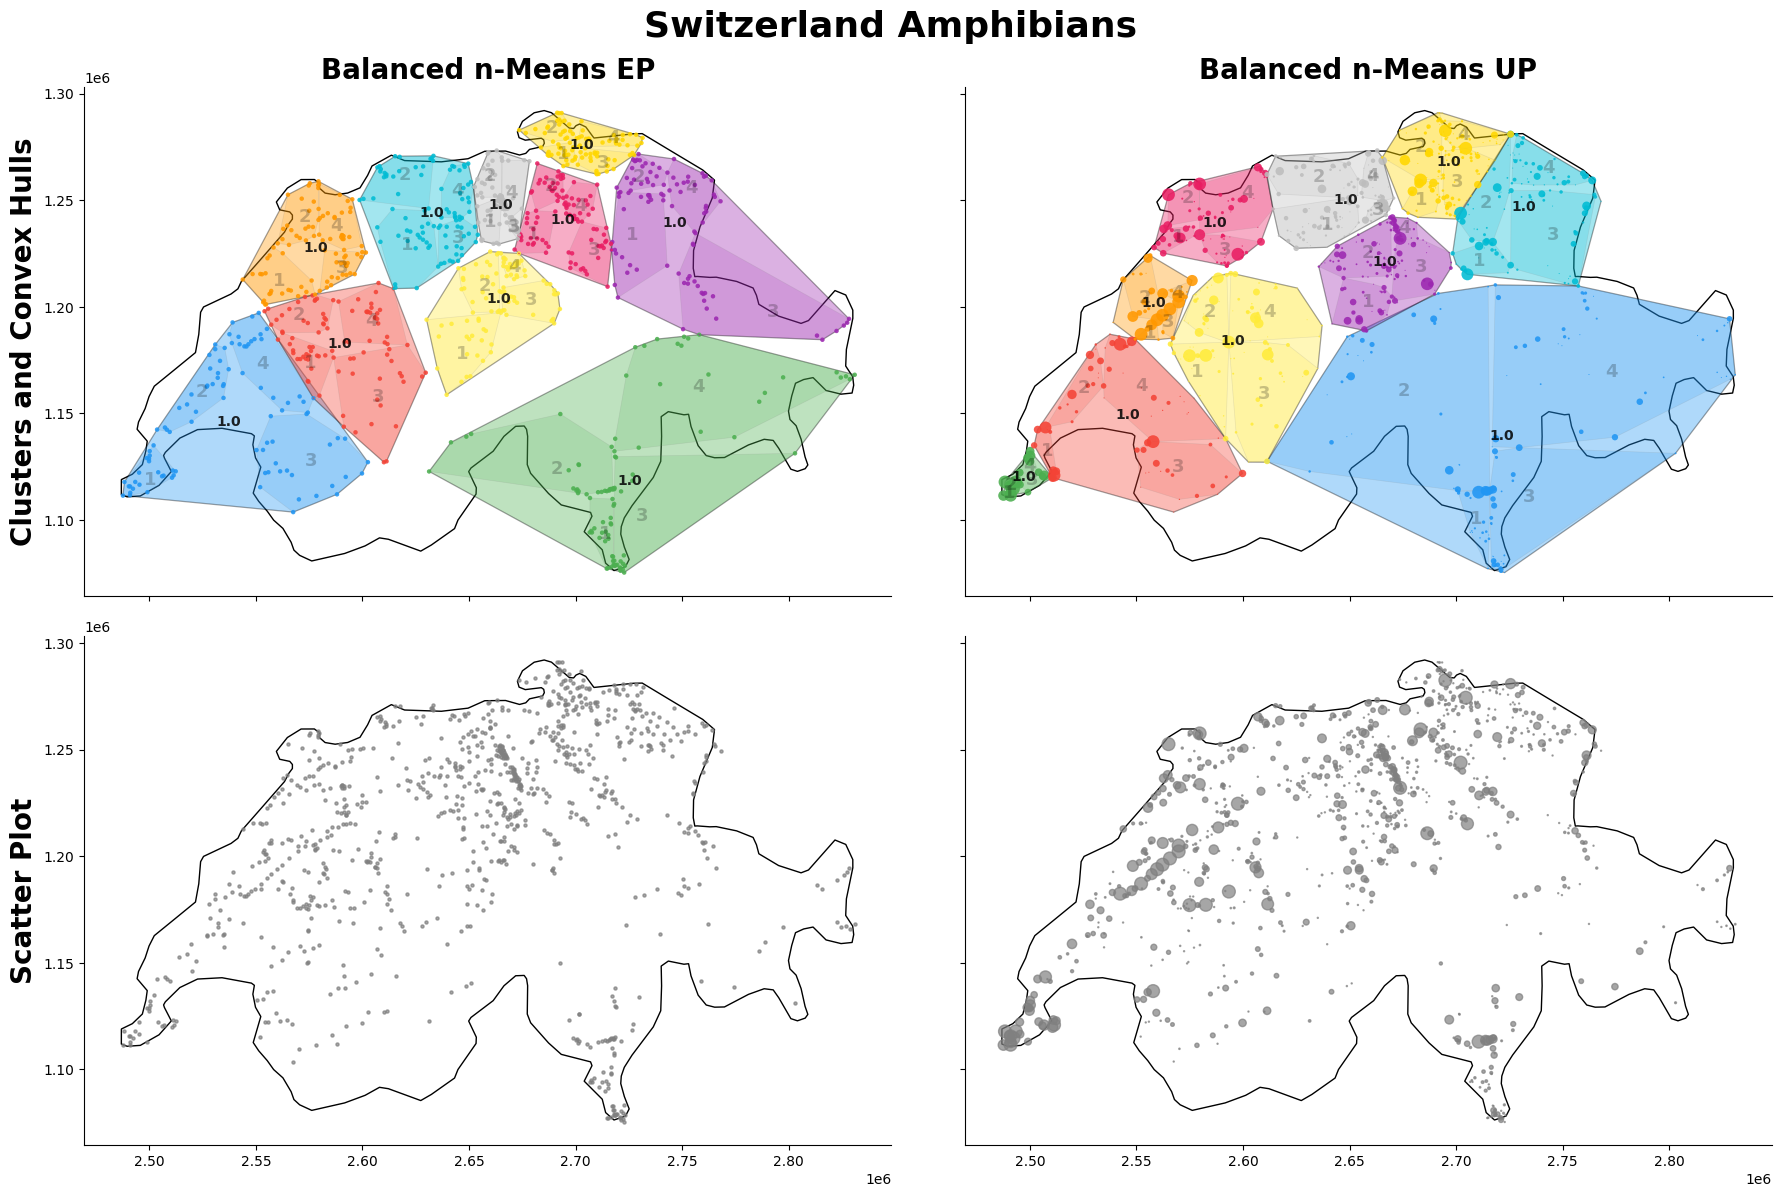

In [ ]:
import matplotlib.pyplot as plt
import geopandas as gpd

swiss_csv = '/home/divar/projects/geometric-sampling/swiss.csv'
swiss_shp = '/home/divar/Downloads/ne_50m_admin_0_countries/ne_50m_admin_0_countries.shp'

world = gpd.read_file(swiss_shp)
swiss_map = world[world['ADMIN'] == 'Switzerland'].to_crs(epsg=2056)

col_labels = [
    "Balanced n-Means EP",
    "Balanced n-Means UP"
]

fig, axes = plt.subplots(2, 2, figsize=(18, 12), sharex=True, sharey=True)

for col, key in enumerate(['swiss_eq', 'swiss_uneq']):
    ax = axes[1, col]
    swiss_map.plot(ax=ax, color="white", edgecolor="black", linewidth=1.0, zorder=0)
    pops = pop_objs[key]
    coords = pops.coords
    probs = pops.probs

    if key == 'swiss_eq':
        # Uniform size
        s = 5
        ax.scatter(coords[:, 0], coords[:, 1], c="gray", s=s, alpha=0.7, zorder=2)
    else:  # 'swiss_uneq'
        # Size proportional to probs, clipped for visibility
        s = probs * 1000  # You can adjust scale/clipping as needed
        ax.scatter(coords[:, 0], coords[:, 1], c="gray", s=s, alpha=0.7, zorder=2)

    
    # ----------- BOTTOM ROW: clusters/hull plot -----------
    ax = axes[0, col]
    
    swiss_map.plot(ax=ax, color="white", edgecolor="black", linewidth=1.0, zorder=0)
    pops.plot(ax=ax)
    ax.set_title("", fontsize=14, fontweight='bold')
    ax.set_aspect("equal")
    if col == 0:
        ax.set_ylabel("Clusters and Convex Hulls", fontsize=20, fontweight='bold')
    ax.set_title(col_labels[col], fontsize=20, fontweight='bold')
    ax.set_aspect("equal")

# Only show left and bottom spines
for ax in axes.flatten():
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[1,0].set_ylabel("Scatter Plot", fontsize=20, fontweight='bold')
plt.tight_layout(rect=[0, 0.01, 1, 0.96])
plt.subplots_adjust(wspace=0.08, hspace=0.08)
plt.suptitle("Switzerland Amphibians", fontsize=26, fontweight='bold', y=0.995)
plt.show()

#### Swiss sampling

In [ ]:
swiss_df = pd.read_csv('/home/divar/projects/geometric-sampling/swiss.csv')
coords = swiss_df[['COORD_X', 'COORD_Y']].to_numpy()
swiss_area_cliped = swiss_df['AREA'].clip(lower=1, upper=150)
N = len(coords)

probs = inclusion_probabilities(swiss_area_cliped, n)


### Gathering Data

In [ ]:
import pandas as pd
import os

folder = "data_samples"
os.makedirs(folder, exist_ok=True)

#   # diactivated to not overwrite some new results!
for name, pop in pop_objs.items():
    # Assuming pop.coords shape (N,2), pop.probs shape (N,)
    df = pd.DataFrame(pop.coords, columns=["x", "y"])
    df["prob"] = pop.probs
    filename = f"{name}.csv"
    df.to_csv(os.path.join(folder, filename), index=False)
    print(f"Saved {filename}")

Saved swiss_eq.csv
Saved swiss_uneq.csv


In [46]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
folder = "data_samples/results"
os.makedirs(folder, exist_ok=True)
all_coords = []
all_probs = []
names = [
    "clust_eq", "clust_uneq",
    "grid_eq", "grid_uneq",
    "random_eq", "random_uneq"
]
# names = [
#     "swiss_uneq",
#     ]
#names = ["random_uneq"]
for name in names:
    df = pd.read_csv(f"data_samples/coords_probs/{name}.csv")
    coords = df[["x", "y"]].values
    probs = df["prob"].values
    all_coords.append(coords)
    all_probs.append(probs)
print(sum(probs))
print(len(probs))
sample_cnt = 2
columns = ["Method", "Density", "Voronoi", "Moran", "Local Balance"]

for coords, probs, name in zip(all_coords, all_probs, names):
    n = int(np.round(np.sum(probs)))
    N =len(probs)
    # Any code for one set, put here:
    sample_methods = find_samples(coords, probs, n, sample_cnt)
    scaled_coords = (coords - np.min(coords, axis=0)) / np.ptp(coords, axis=0)
    density_measure = gs.measure.Density(scaled_coords, probs, n, split_size=0.001)
    rows = np.array([
    [method, *scores(coords, probs, n, N, s, density_measure)]
    for method, samples in sample_methods.items()
    if samples is not None  # <----- add this
    for s in tqdm(samples, total=sample_cnt)
])
    df = pd.DataFrame(rows, columns=columns)
    df = df.astype({
        "Density": float,
        "Voronoi": float,
        "Moran": float,
        "Local Balance": float
    })
    filename = os.path.join(folder, f"initial_results_{name}.csv")
    df.to_csv(filename, index=False)
    print(f"Saved: {filename}")

3.9999999999999782
400


100%|██████████| 2/2 [00:02<00:00,  1.46s/it]


Saved: data_samples/results/initial_results_clust_eq.csv


100%|██████████| 2/2 [00:01<00:00,  1.37it/s]


Saved: data_samples/results/initial_results_clust_uneq.csv


...

Saved: data_samples/results/initial_results_grid_uneq.csv


100%|██████████| 2/2 [00:01<00:00,  1.17it/s]


Saved: data_samples/results/initial_results_random_eq.csv


100%|██████████| 2/2 [00:02<00:00,  1.31s/it]

Saved: data_samples/results/initial_results_random_uneq.csv


In [ ]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm

folder = "data_samples"
os.makedirs(folder, exist_ok=True)

# List all _eq.csv data files for processing
data_files = [f for f in os.listdir(folder) if f.endswith("_eq.csv") and not f.startswith("results_")]

sample_cnt = 1000
columns = ["Method", "Density", "Voronoi", "Moran", "Local Balance"]

for data_file in data_files:
    # Set up base names
    case_name = data_file.replace(".csv", "")
    result_file = os.path.join(folder, f"results_{case_name}.csv")

    print(f"Processing: {data_file} -> {result_file}")
    # Load input data
    df = pd.read_csv(os.path.join(folder, data_file))
    coords = df[["x", "y"]].values
    probs = df["prob"].values
    n = int(np.round(np.sum(probs)))
    N = len(probs)

    # Your existing scoring infrastructure
    #scaled_coords = (coords - np.min(coords, axis=0)) / np.ptp(coords, axis=0)
    density_measure = gs.measure.Density(coords, probs, n, split_size=0.001)

    # Load or create results file
    if os.path.exists(result_file):
        df_results = pd.read_csv(result_file)
    else:
        df_results = pd.DataFrame(columns=columns)

    # Get only the two new methods for equal probability cases
    sample_methods = find_samples(coords, probs, n, sample_cnt, ep_mode="EP")

    for method in ["spcosa"]:
        samples = sample_methods.get(method)
        if samples is not None:
            new_rows = np.array([
                [method, *scores(coords, probs, n, N, s, density_measure)]
                for s in tqdm(samples, total=sample_cnt, desc=f"{method} - {case_name}")
            ])
            df_new = pd.DataFrame(new_rows, columns=columns)
            df_new = df_new.astype({
                "Density": float,
                "Voronoi": float,
                "Moran": float,
                "Local Balance": float
            })
            df_results = pd.concat([df_results, df_new], ignore_index=True)

    df_results.to_csv(result_file, index=False)
    print(f"Saved: {result_file}")

Processing: clust_eq.csv -> data_samples/results_clust_eq.csv


R[write to console]: Loading required package: rJava

R[write to console]: Error: package or namespace load failed for ‘rJava’:
 .onLoad failed in loadNamespace() for 'rJava', details:
  call: dyn.load(file, DLLpath = DLLpath, ...)
  error: unable to load shared object '/usr/lib/R/site-library/rJava/libs/rJava.so':
  libjvm.so: cannot open shared object file: No such file or directory

R[write to console]: Error: package ‘rJava’ could not be loaded



RRuntimeError: Error: package ‘rJava’ could not be loaded


In [ ]:
results_dict = {}

for name in names:
    df = pd.read_csv(os.path.join(folder, f"results_{name}.csv"))
    results_dict[name] = df

FileNotFoundError: [Errno 2] No such file or directory: 'data_samples/results_swiss_uneq.csv'

## Results

In [ ]:
df = results_dict["grid_eq"]

In [ ]:
%load_ext autoreload
%autoreload 2
import geometric_sampling as gs

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


##### Three Population

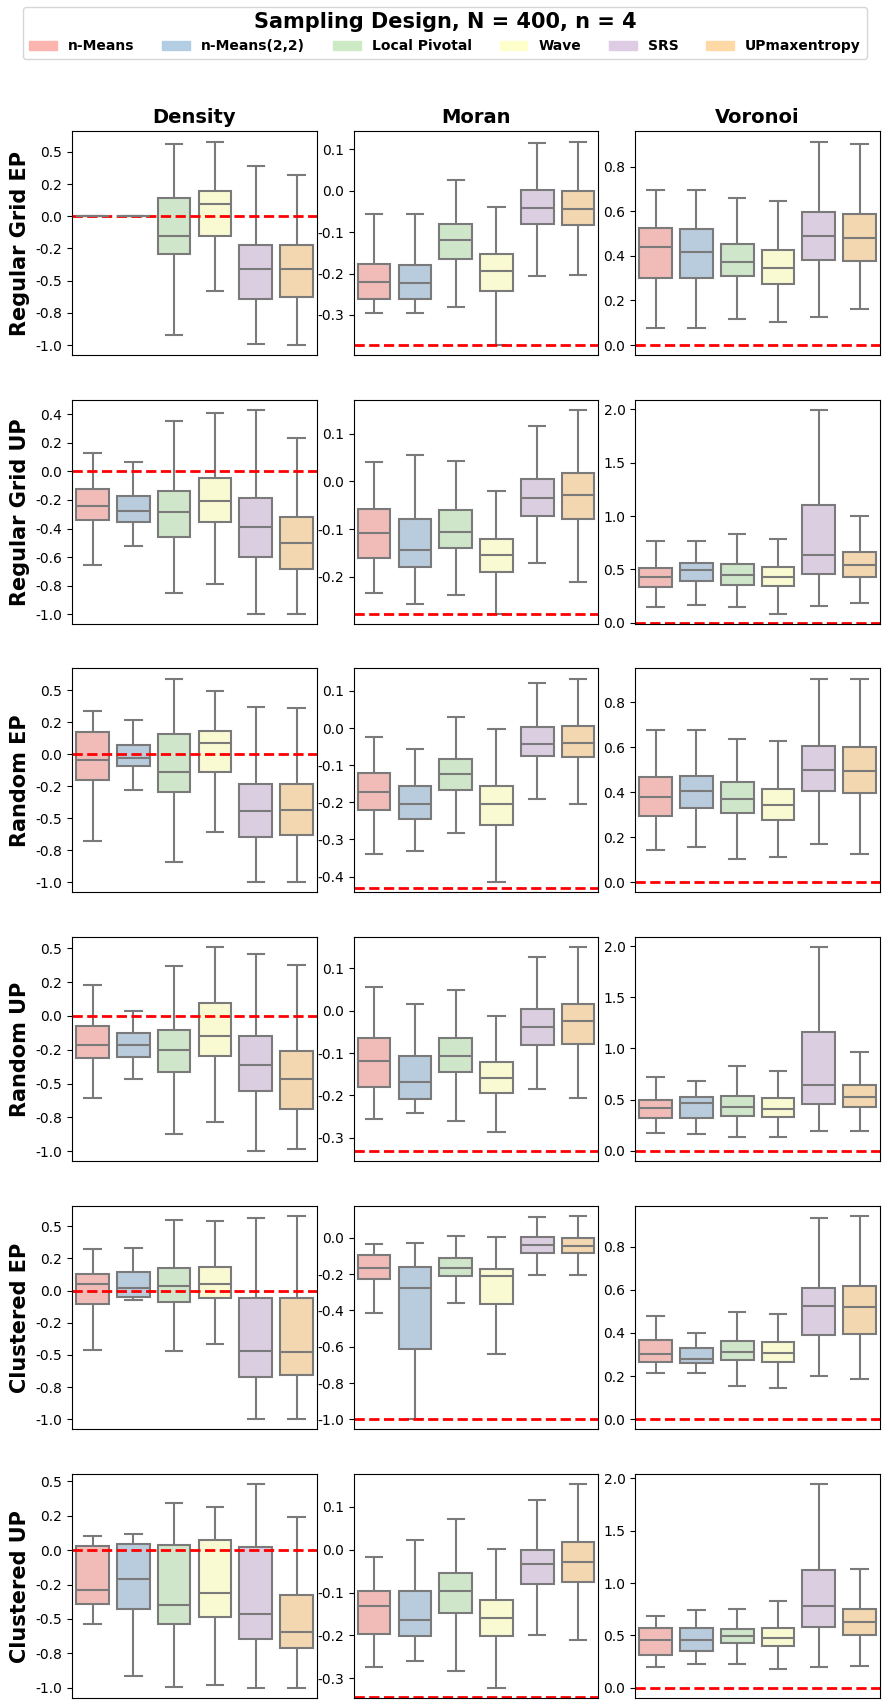

In [167]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from matplotlib.ticker import FuncFormatter

warnings.filterwarnings('ignore')

# Folder and file info
method_order = ["n-Means", "n-Means(2,2)", "Local Pivotal", "Wave", "SRS", "UPmaxentropy"]
results_folder = 'data_samples/results'
result_files = [
    "results_grid_eq.csv",
    "results_grid_uneq.csv",
    "results_random_eq.csv",
    "results_random_uneq.csv",
    "results_clust_eq.csv",
    "results_clust_uneq.csv",
    # "results_swiss_eq_n=10.csv",
    # "results_swiss_uneq_n=10.csv",
]
pretty_names = {
    "grid_eq": "Regular Grid Equal FIP",
    "grid_uneq": "Regular Grid Unequal FIP",
    "random_eq": "Random Equal FIP",
    "random_uneq": "Random Unequal FIP",
    "clust_eq": "Clustered Equal FIP",
    "clust_uneq": "Clustered Unequal FIP",
}

pretty_names = {
    "grid_eq": "Regular Grid EP",
    "grid_uneq": "Regular Grid UP",
    "random_eq": "Random EP",
    "random_uneq": "Random UP",
    "clust_eq": "Clustered EP",
    "clust_uneq": "Clustered UP",
}

# Use the new column for plotting (x or hue):
pop_names = [s.replace("results_", "").replace(".csv", "") for s in result_files]

# Read results into a dict
colnames = ["Method", "Density", "Moran", "Voronoi"]
results_dict = {}
for name, fname in zip(pop_names, result_files):
    df = pd.read_csv(os.path.join(results_folder, fname), names=colnames, header=None)
    results_dict[name] = df

# Mapping for nicer method names
method_name_mapping = {
    "K-Means (1, 1)": "n-Means",
    "K-Means (3, 3)": "n-Means(2,2)",
    "Local Pivotal": "Local Pivotal",
    "wave": "Wave",
    "Random": "SRS",
    "UPmaxentropy": "UPmaxentropy"
}

# Apply the mapping to ALL dataframes in your results_dict
for df in results_dict.values():
    df["Method"] = df["Method"].map(method_name_mapping)

# OPTIONAL: Remove any 'Method Pretty' columns if you made them previously
for df in results_dict.values():
    if "Method Pretty" in df.columns:
        df.drop(columns=["Method Pretty"], inplace=True)
# Method palette for coloring
all_methods = pd.concat(list(results_dict.values()))["Method"].unique()
method_palette = dict(zip(all_methods, sns.color_palette("Pastel1", n_colors=len(all_methods))))

# Metrics
columns = [c for c in results_dict[pop_names[0]].columns if c != "Method"]
#columns = [columns[i] for i in [0, 2, 1, 3]]

# Create 6x4 grid (6 populations, 4 metrics)
n_rows = len(pop_names)
n_cols = len(columns)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 3*n_rows), sharey=False)

for row_idx, pop in enumerate(pop_names):
    df_pop = results_dict[pop]
    for col_idx, metric in enumerate(columns):
        ax = axes[row_idx, col_idx]
        sns.boxplot(
            x="Method",
            y=metric,
            data=df_pop[df_pop[metric] < 2],  # <--- Filter here!
#            data=df_pop, #remove_outliers(df_pop, metric, IQR_coef=10, groupby_col="Method"),
            hue="Method",  # always assign hue for consistent handles
            palette=method_palette,
            ax=ax,
            order=method_order,
            showfliers=False,
            linewidth=1.5,
            #boxprops=dict(color='black'),
            #whiskerprops=dict(color='black'),
            #capprops=dict(color='black'),
            #medianprops=dict(color='black'),
        )
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()
        ax.tick_params(axis='x', length=0)  # This removes the little black lines (ticks) on the x-axis
        #ax.grid(True)
        if row_idx == 0:
            ax.set_title(f"{metric}", fontsize=14, weight='bold')
        else:
            ax.set_title("")
        if col_idx == 0:
            ax.set_ylabel(pretty_names.get(pop, pop), weight='bold', fontsize=15)
        else:
            ax.set_ylabel("")
        ax.set_xlabel("")
        ax.set_xticklabels([])
        if not (row_idx == 0 and col_idx == 0):
            legend = ax.get_legend()
            if legend is not None:
                legend.remove()
        ax.tick_params(axis='y', labelsize=10)
        ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.1f}"))  # 2 decimals
        if metric in ['Density', 'Voronoi', 'Local Balance']:
            ax.axhline(y=0, color='red', linestyle='--', linewidth=2)
        else:
            ax.axhline(y=min(df_pop['Moran']), color='red', linestyle='--', linewidth=2)
# ... rest of your code as above ...

# ----------- SHARED LEGEND BLOCK (robust dummy plot method) -----------
fig_legend, ax_legend = plt.subplots()
df_concat = pd.concat(list(results_dict.values()), ignore_index=True)

# NOTE: Only use x="Method", NOT hue!
sns.boxplot(
    x="Method",
    y=columns[0],
    data=df_concat,
    palette=method_palette,
    ax=ax_legend,
    showfliers=False
)

from matplotlib.patches import Patch
labels = method_order
handles = [Patch(color=method_palette[l]) for l in labels]
plt.close(fig_legend)
leg = fig.legend(
    handles, labels, loc='upper center', ncol=len(all_methods),
    title="Sampling Design, N = 400, n = 4",
    fontsize=10,              # Label size
    title_fontsize=15         # Title size
    # No fontweight argument directly here
)

# Make legend labels bold
for text in leg.get_texts():
    text.set_fontweight('bold')

# Make legend title bold
leg.get_title().set_fontweight('bold')
fig.tight_layout(rect=[0, 0.05, 1, 0.95])
fig.subplots_adjust(wspace=0.15, hspace=0.2)
# fig.suptitle("All metrics for all populations", fontsize=16, y=1.01)
plt.show()

##### Swiss

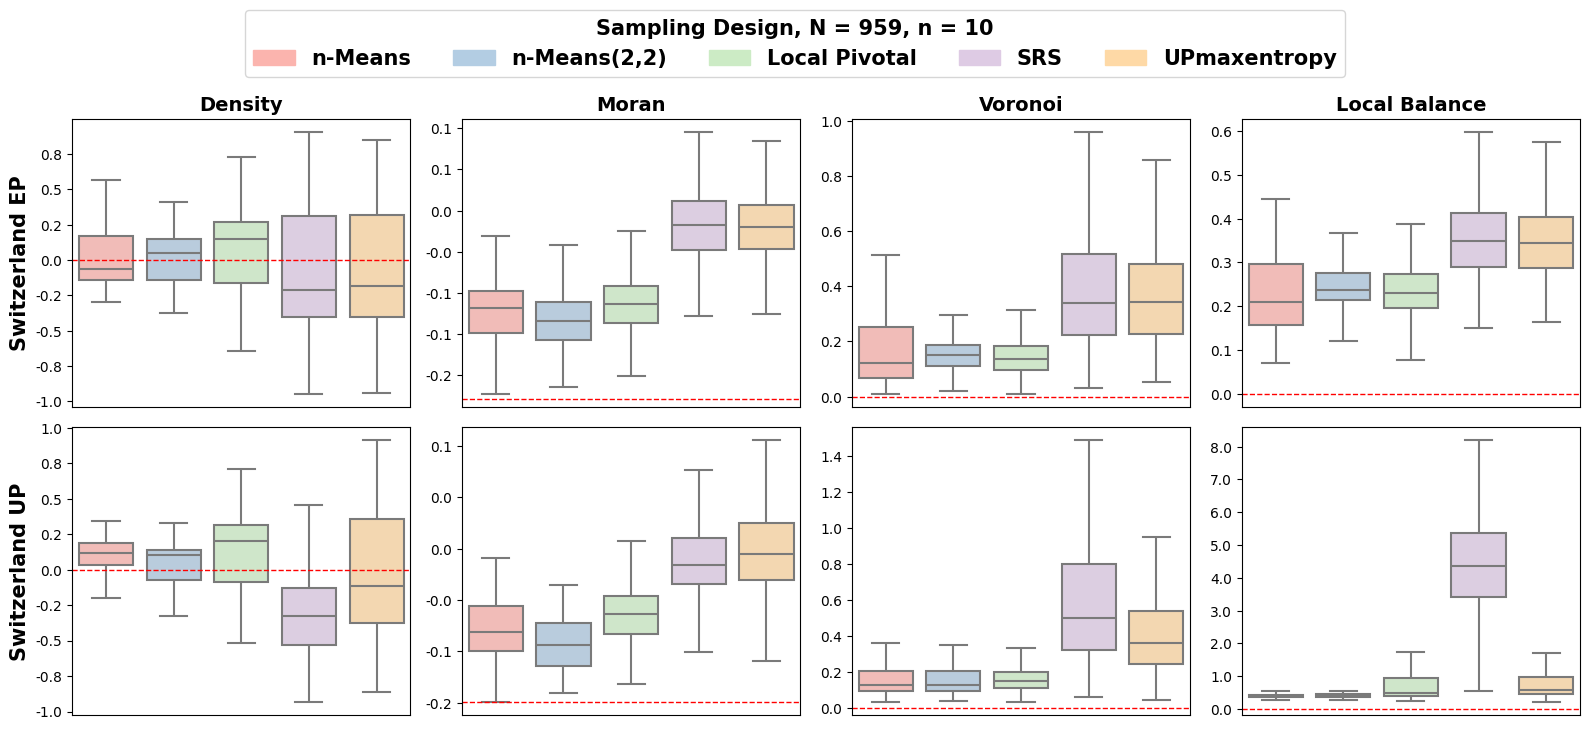

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from matplotlib.ticker import FuncFormatter

warnings.filterwarnings('ignore')

# Folder and file info
method_order = ["n-Means", "n-Means(2,2)", "Local Pivotal", "SRS", "UPmaxentropy"]
results_folder = 'data_samples'
result_files = [
    "results_swiss_eq_n=10.csv",
    "results_swiss_uneq_n=10.csv",
]
pretty_names = {
    "swiss_eq_n=10": "Switzerland EP",
    "swiss_uneq_n=10": "Switzerland UP",
}

# Use the new column for plotting (x or hue):
pop_names = [s.replace("results_", "").replace(".csv", "") for s in result_files]

# Read results into a dict
results_dict = {
    name: pd.read_csv(os.path.join(results_folder, fname))
    for name, fname in zip(pop_names, result_files)
}
# Mapping for nicer method names
method_name_mapping = {
    "K-Means (1, 1)": "n-Means",
    "K-Means (2, 2)": "n-Means(2,2)",
    "Local Pivotal": "Local Pivotal",
    "Random": "SRS",
    "UPmaxentropy": "UPmaxentropy"
}

# Apply the mapping to ALL dataframes in your results_dict
for df in results_dict.values():
    df["Method"] = df["Method"].map(method_name_mapping)

# OPTIONAL: Remove any 'Method Pretty' columns if you made them previously
for df in results_dict.values():
    if "Method Pretty" in df.columns:
        df.drop(columns=["Method Pretty"], inplace=True)
# Method palette for coloring
all_methods = pd.concat(list(results_dict.values()))["Method"].unique()
method_palette = dict(zip(all_methods, sns.color_palette("Pastel1", n_colors=len(all_methods))))


# Metrics
columns = [c for c in results_dict[pop_names[0]].columns if c != "Method"]
columns = [columns[i] for i in [0, 2, 1, 3]]

# Create 6x4 grid (6 populations, 4 metrics)
n_rows = len(pop_names)
n_cols = len(columns)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows), sharey=False)

for row_idx, pop in enumerate(pop_names):
    df_pop = results_dict[pop]
    for col_idx, metric in enumerate(columns):
        ax = axes[row_idx, col_idx]
        sns.boxplot(
            x="Method",
            y=metric,
            data=df_pop,#[df_pop[metric] < 2],  # <--- Filter here!
#            data=df_pop, #remove_outliers(df_pop, metric, IQR_coef=10, groupby_col="Method"),
            hue="Method",  # always assign hue for consistent handles
            palette=method_palette,
            ax=ax,
            order=method_order,
            showfliers=False,
            linewidth=1.5

        )
        #ax.grid(True)
        ax.tick_params(axis='x', length=0)  # This removes the little black lines (ticks) on the x-axis
        #ax.grid(True)
        if row_idx == 0:
            ax.set_title(f"{metric}", fontsize=14, weight='bold')
        else:
            ax.set_title("")
        if col_idx == 0:
            ax.set_ylabel(pretty_names.get(pop, pop), weight='bold', fontsize=15)
        else:
            ax.set_ylabel("")
        ax.set_xticklabels([])
        if not (row_idx == 0 and col_idx == 0):
            legend = ax.get_legend()
            if legend is not None:
                legend.remove()
        ax.tick_params(axis='y', labelsize=10)
        ax.set_xlabel("")
        ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.1f}"))  # 2 decimals
        if metric in ['Density', 'Voronoi', 'Local Balance']:
            ax.axhline(y=0, color='red', linestyle='--', linewidth=1)
        else:
            ax.axhline(y=min(df_pop['Moran']), color='red', linestyle='--', linewidth=1)
# ... rest of your code as above ...

# ----------- SHARED LEGEND BLOCK (robust dummy plot method) -----------
fig_legend, ax_legend = plt.subplots()
df_concat = pd.concat(list(results_dict.values()), ignore_index=True)

# NOTE: Only use x="Method", NOT hue!
sns.boxplot(
    x="Method",
    y=columns[0],
    data=df_concat,
    palette=method_palette,
    ax=ax_legend,
    showfliers=False
)
handles, labels = ax_legend.get_legend_handles_labels()

# If still empty, use get_xticklabels instead:
if all([h is None for h in handles]) or not handles:
    labels = [t.get_text() for t in ax_legend.get_xticklabels()]
    from matplotlib.patches import Patch
    handles = [Patch(color=method_palette[l]) for l in labels]

plt.close(fig_legend)

leg = fig.legend(
    handles, labels, loc='upper center', ncol=len(all_methods),
    title="Sampling Design, N = 959, n = 10",
    fontsize=15,              # Label size
    title_fontsize=15         # Title size
    # No fontweight argument directly here
)

# Make legend labels bold
for text in leg.get_texts():
    text.set_fontweight('bold')

# Make legend title bold
leg.get_title().set_fontweight('bold')

# ----------------------------------------------------------------------
fig.tight_layout(rect=[0, 0.08, 1, 1])  # Increase lower value (0.05→0.08)
fig.subplots_adjust(top=0.85)  # Fine tune if title/legend crowds# fig.suptitle("All metrics for all populations", fontsize=16, y=1.01)
plt.show()

# Store


In [ ]:
len(probs)

NameError: name 'probs' is not defined

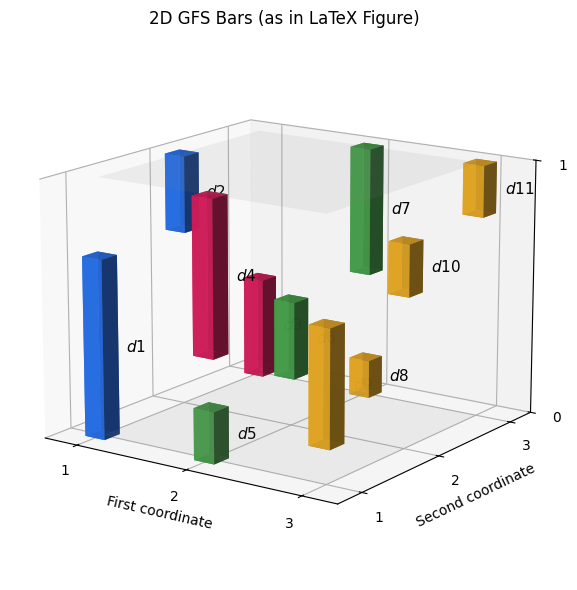

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

bars_3d = [
    # x, y, z_start, z_end, label, color
    (1, 1, 0.0, 0.7, 'd1', 'myblue'),
    (1, 2, 0.7, 1.0, 'd2', 'myblue'),
    (1, 3, 0.0, 0.4, 'd3', 'myred'),
    (2, 1, 0.4, 1.0, 'd4', 'myred'),
    (2, 1, 0.0, 0.2, 'd5', 'mygreen'),
    (2, 2, 0.2, 0.5, 'd6', 'mygreen'),
    (2, 3, 0.5, 1.0, 'd7', 'mygreen'),
    (2, 3, 0.0, 0.15, 'd8', 'mygold'),
    (3, 1, 0.15, 0.6, 'd9', 'mygold'),
    (3, 2, 0.6, 0.8, 'd10', 'mygold'),
    (3, 3, 0.8, 1.0, 'd11', 'mygold'),
]

color_dict = {
    "myblue": "#2979FF",
    "myred": "#E91E63",
    "mygreen": "#4CAF50",
    "mygold": "#FDB827",
    "mypurple": "#9C27B0",
}

fig = plt.figure(figsize=(11, 6))
ax = fig.add_subplot(111, projection='3d')

dx = dy = 0.18  # bar thickness

for (x, y, z1, z2, label, cgroup) in bars_3d:
    height = z2 - z1
    ax.bar3d(x - dx/2, y - dy/2, z1, dx, dy, height, color=color_dict[cgroup], alpha=0.85)
    ax.text(x + dx/2 + 0.07, y + dy/2, (z1+z2)/2, f"${label}$", fontsize=11, va='center', ha='left')

# Draw "floors" at z=0 and z=1
for z, alpha in [(0, 0.1), (1, 0.1)]:
    X, Y = np.meshgrid([1,2,3], [1,2,3])
    Z = np.full_like(X, z)
    ax.plot_surface(X, Y, Z, color='gray', alpha=alpha, shade=False)

ax.set_xlim(0.7,3.3)
ax.set_ylim(0.7,3.3)
ax.set_zlim(0,1)
ax.set_xlabel("First coordinate")
ax.set_ylabel("Second coordinate")
ax.set_zlabel("Inclusion Probabilities")
ax.set_xticks([1,2,3])
ax.set_yticks([1,2,3])
ax.set_zticks([0,1])
ax.view_init(elev=15, azim=-55)
ax.set_title("2D GFS Bars (as in LaTeX Figure)")

plt.tight_layout()
plt.show()

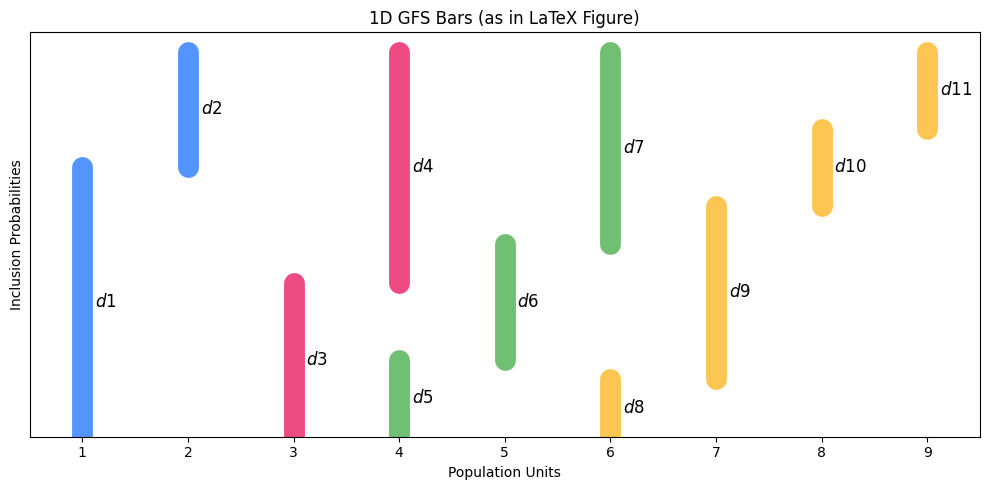

In [ ]:
import matplotlib.pyplot as plt

# Coordinates for each bar segment: (x, y_start, y_end, label)
bars = [
    (1, 0.0, 0.7, 'd1', 'myblue'),
    (2, 0.7, 1.0, 'd2', 'myblue'),
    (3, 0.0, 0.4, 'd3', 'myred'),
    (4, 0.4, 1.0, 'd4', 'myred'),
    (4, 0.0, 0.2, 'd5', 'mygreen'),
    (5, 0.2, 0.5, 'd6', 'mygreen'),
    (6, 0.5, 1.0, 'd7', 'mygreen'),
    (6, 0.0, 0.15, 'd8', 'mygold'),
    (7, 0.15, 0.6, 'd9', 'mygold'),
    (8, 0.6, 0.8, 'd10', 'mygold'),
    (9, 0.8, 1.0, 'd11', 'mygold'),
]

color_dict = {
    "myblue": "#2979FF",
    "myred": "#E91E63",
    "mygreen": "#4CAF50",
    "mygold": "#FDB827",
    "mypurple": "#9C27B0",
}

fig, ax = plt.subplots(figsize=(10, 5))

for (x, y1, y2, label, cgroup) in bars:
    ax.plot([x, x], [y1, y2], color=color_dict[cgroup], lw=15, alpha=0.8, solid_capstyle='round')
    ax.text(x+0.12, (y1+y2)/2, f"${label}$", va='center', fontsize=12)

ax.set_xlim(0.5, 9.5)
ax.set_ylim(0, 1.05)
ax.set_xticks(range(1, 10))
ax.set_yticks([])
ax.set_xlabel("Population Units")
ax.set_ylabel("Inclusion Probabilities")
ax.grid(axis='y', linestyle='dashed', alpha=0.5)
ax.set_title("1D GFS Bars (as in LaTeX Figure)")

plt.tight_layout()
plt.show()